# OpenAlex Citation Analysis Prototype
## Inferred author gender, authorship composition, and citation impact

**Prototype:** 200 samples from each:

1. Subfield `3309`
2. Subfield `1710`
3. Keyword `information-retrieval`
total 600

RQs:
1) % of authors F vs M%
2) % of Only F/ Only M authors
3) First author % comparision
4) across discipline/ keywords
5) trend over the years for author %
6) citation comparision F/M
7) % overlap between subfields


- Unknown/ambiguous names are retained.
- Citation counts accumulate over time; publication year must be considered.

In [ ]:
# Run once if the packages are not already installed.
%pip install -q requests pandas numpy matplotlib scipy statsmodels gender-guesser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.3/379.3 kB 6.1 MB/s eta 0:00:00


## 1. Imports and reproducibility

In [ ]:
import os
import re
import time
import json
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import gender_guesser.detector as gender

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

RANDOM_SEED = 202609
N_PER_CORPUS = 500
EXTRACTION_UTC = datetime.now(timezone.utc).isoformat()

print("Extraction UTC:", EXTRACTION_UTC)

Extraction UTC: 2026-09-06T02:22:00.279130+00:00


## 2. OpenAlex API configuration

In [ ]:
OPENALEX_API_KEY = os.getenv("OPENALEX_API_KEY", "").strip()
OPENALEX_API_KEY = "Eqdz5TEPEGwnGU4VcIXC3H"

BASE_URL = "https://api.openalex.org"

session = requests.Session()
session.headers.update({"User-Agent": "OpenAlex-gender-citation-prototype/1.0"})

def with_key(params=None):
    p = dict(params or {})
    if OPENALEX_API_KEY:
        p["api_key"] = OPENALEX_API_KEY
    return p

if not OPENALEX_API_KEY:
    print("No API key detected. Add one if OpenAlex rejects/limits the requests.")

## 3. Define the three corpora


In [ ]:
CORPORA = {
    "subfield_3309": {
        "entity_type": "subfields",
        "entity_id": "3309",
        "filter": "primary_topic.subfield.id:3309",
    },
    "subfield_1710": {
        "entity_type": "subfields",
        "entity_id": "1710",
        "filter": "primary_topic.subfield.id:1710",
    },
    "keyword_information_retrieval": {
        "entity_type": "keywords",
        "entity_id": "information-retrieval",
        "filter": "keywords.id:information-retrieval",
    },
}

def get_entity_metadata(entity_type, entity_id):
    r = session.get(
        f"{BASE_URL}/{entity_type}/{entity_id}",
        params=with_key(),
        timeout=60
    )
    r.raise_for_status()
    return r.json()

for key, cfg in CORPORA.items():
    meta = get_entity_metadata(cfg["entity_type"], cfg["entity_id"])
    cfg["display_name"] = meta.get("display_name")
    cfg["works_count_openalex"] = meta.get("works_count")
    print(key, "->", cfg["display_name"], "| works_count:", cfg["works_count_openalex"])

subfield_3309 -> Library and Information Sciences | works_count: 314604
subfield_1710 -> Information Systems | works_count: 4436568
keyword_information_retrieval -> Information retrieval | works_count: 2525122


## 4. Retrieve 500 samples

OpenAlex list responses are capped at 100 records per page, so the function paginates.
The fixed `seed` makes sampling reproducible relative to the current OpenAlex database state.

In [ ]:
WORK_SELECT = ",".join([
    "id","doi","display_name","publication_year","publication_date","type",
    "cited_by_count","fwci","citation_normalized_percentile",
    "authorships","primary_topic","topics","keywords"
])

def fetch_sampled_works(filter_string, n=200, seed=RANDOM_SEED):
    rows = []
    page = 1

    while len(rows) < n:
        per_page = min(100, n - len(rows))
        params = with_key({
            "filter": filter_string,
            "sample": n,
            "seed": seed,
            "per_page": per_page,
            "page": page,
            "select": WORK_SELECT,
        })

        r = session.get(f"{BASE_URL}/works", params=params, timeout=120)
        r.raise_for_status()
        batch = r.json().get("results", [])
        if not batch:
            break

        rows.extend(batch)
        page += 1
        time.sleep(0.15)

    # defensive deduplication
    unique = {}
    for w in rows:
        unique[w["id"]] = w
    works = list(unique.values())[:n]

    if len(works) < n:
        raise RuntimeError(
            f"Only {len(works)} unique works retrieved; expected {n}. "
            "Inspect current OpenAlex sample/pagination behavior."
        )
    return works

raw_works_by_corpus = {}

for i, (key, cfg) in enumerate(CORPORA.items()):
    works = fetch_sampled_works(
        cfg["filter"],
        n=N_PER_CORPUS,
        seed=RANDOM_SEED + i
    )
    raw_works_by_corpus[key] = works
    print(key, len(works))

subfield_3309 500
subfield_1710 500
keyword_information_retrieval 500


## 5. Check overlap between the three sampled corpora


In [ ]:
work_sets = {
    k: {w["id"] for w in works}
    for k, works in raw_works_by_corpus.items()
}

keys = list(work_sets)
overlap = pd.DataFrame(index=keys, columns=keys, dtype=int)

for a in keys:
    for b in keys:
        overlap.loc[a, b] = len(work_sets[a] & work_sets[b])

display(overlap)

memberships = sum(len(s) for s in work_sets.values())
unique_works = len(set().union(*work_sets.values()))
print("Corpus memberships:", memberships)
print("Unique works:", unique_works)
print("Overlap memberships:", memberships - unique_works)

,subfield_3309,subfield_1710,keyword_information_retrieval
subfield_3309,500.0,0.0,0.0
subfield_1710,0.0,500.0,0.0
keyword_information_retrieval,0.0,0.0,500.0


Corpus memberships: 1500
Unique works: 1500
Overlap memberships: 0


## 6. Infer gender from the author's given name

surnames should not be treated as given names.
- We need to figure out if they give surname + name or vice-versa

In [ ]:
detector = gender.Detector(case_sensitive=False)

def normalize_spaces(x):
    return re.sub(r"\s+", " ", (x or "").strip())

def strip_diacritics(x):
    x = unicodedata.normalize("NFKD", x or "")
    return "".join(c for c in x if not unicodedata.combining(c))

def extract_given_name(full_name):
    name = normalize_spaces(full_name)
    if not name:
        return None

    # Common Western bibliographic form: "Last, First Middle"
    if "," in name:
        _, right = name.split(",", 1)
        candidate_part = normalize_spaces(right)
    else:
        candidate_part = name

    if not candidate_part:
        return None

    token = candidate_part.split()[0]
    token = re.sub(
        r"^[^A-Za-zÀ-ÖØ-öø-ÿĀ-ž]+|[^A-Za-zÀ-ÖØ-öø-ÿĀ-ž'’-]+$",
        "",
        token
    )

    letters = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿĀ-ž]", "", token)
    if len(letters) <= 1:
        return None

    return token or None

def infer_gender_from_name(full_name):
    given = extract_given_name(full_name)

    if not given:
        return given, "unknown", "unusable_or_initial"

    candidates = [given]
    stripped = strip_diacritics(given)
    if stripped and stripped != given:
        candidates.append(stripped)

    raw = "unknown"
    for candidate in candidates:
        raw = detector.get_gender(candidate)
        if raw != "unknown":
            break

    if raw in {"male", "mostly_male"}:
        inferred = "male"
    elif raw in {"female", "mostly_female"}:
        inferred = "female"
    else:
        inferred = "unknown"

    return given, inferred, raw

for example in ["Thomas Mandl", "Khushi Pitroda","Pitroda Khushi","Aenne Knierim","Katja Lapshinova"]:
    print(example, "->", infer_gender_from_name(example))

Thomas Mandl -> ('Thomas', 'male', 'male')
Khushi Pitroda -> ('Khushi', 'unknown', 'unknown')
Pitroda Khushi -> ('Pitroda', 'unknown', 'unknown')
Aenne Knierim -> ('Aenne', 'female', 'female')
Katja Lapshinova -> ('Katja', 'female', 'female')


## 7. Building author-level and paper-level datasets

`authors_df`: one row per authorship per corpus membership.  
`papers_df`: one row per paper per corpus membership.

OpenAlex's explicit `author_position == "first"` is used for first-author analysis.

In [ ]:
def short_id(x):
    return None if not x else str(x).rstrip("/").split("/")[-1]

author_rows = []
paper_rows = []

for corpus_key, works in raw_works_by_corpus.items():
    corpus_name = CORPORA[corpus_key]["display_name"]

    for w in works:
        work_id = short_id(w.get("id"))
        authorships = w.get("authorships") or []
        local_authors = []

        for a in authorships:
            author_obj = a.get("author") or {}
            author_name = (
                a.get("raw_author_name")
                or author_obj.get("display_name")
                or ""
            )

            given, inferred, raw_guess = infer_gender_from_name(author_name)

            row = {
                "corpus_key": corpus_key,
                "corpus_name": corpus_name,
                "work_id": work_id,
                "author_id": short_id(author_obj.get("id")),
                "author_name": author_name,
                "given_name_parsed": given,
                "gender_inferred": inferred,
                "gender_guesser_raw": raw_guess,
                "author_position": a.get("author_position"),
                "is_corresponding": a.get("is_corresponding"),
            }
            author_rows.append(row)
            local_authors.append(row)

        genders = [a["gender_inferred"] for a in local_authors]
        n_female = sum(g == "female" for g in genders)
        n_male = sum(g == "male" for g in genders)
        n_unknown = sum(g == "unknown" for g in genders)
        n_authors = len(local_authors)
        n_known_binary = n_female + n_male

        first_candidates = [
            a for a in local_authors
            if a["author_position"] == "first"
        ]
        first = first_candidates[0] if first_candidates else None

        pt = w.get("primary_topic") or {}
        sf = pt.get("subfield") or {}
        fld = pt.get("field") or {}
        dom = pt.get("domain") or {}
        cnp = w.get("citation_normalized_percentile") or {}

        paper_rows.append({
            "corpus_key": corpus_key,
            "corpus_name": corpus_name,
            "work_id": work_id,
            "doi": w.get("doi"),
            "title": w.get("display_name"),
            "publication_year": w.get("publication_year"),
            "publication_date": w.get("publication_date"),
            "work_type": w.get("type"),
            "cited_by_count": w.get("cited_by_count"),
            "fwci": w.get("fwci"),
            "citation_normalized_percentile": cnp.get("value"),
            "primary_topic_id": short_id(pt.get("id")),
            "primary_topic_name": pt.get("display_name"),
            "primary_subfield_id": short_id(sf.get("id")),
            "primary_subfield_name": sf.get("display_name"),
            "primary_field_id": short_id(fld.get("id")),
            "primary_field_name": fld.get("display_name"),
            "primary_domain_id": short_id(dom.get("id")),
            "primary_domain_name": dom.get("display_name"),
            "n_authors_openalex": n_authors,
            "n_inferred_female": n_female,
            "n_inferred_male": n_male,
            "n_unknown_gender": n_unknown,
            "n_binary_known_gender": n_known_binary,
            "female_author_share_inferred": (
                n_female / n_known_binary if n_known_binary else np.nan
            ),
            "male_author_share_inferred": (
                n_male / n_known_binary if n_known_binary else np.nan
            ),
            "unknown_author_share": (
                n_unknown / n_authors if n_authors else np.nan
            ),
            "first_author_id": first["author_id"] if first else None,
            "first_author_name": first["author_name"] if first else None,
            "first_author_given_name": first["given_name_parsed"] if first else None,
            "first_author_gender_inferred": (
                first["gender_inferred"] if first else "unknown"
            ),
            "first_author_gender_guesser_raw": (
                first["gender_guesser_raw"] if first else "missing_first_authorship"
            ),
        })

authors_df = pd.DataFrame(author_rows)
papers_df = pd.DataFrame(paper_rows)

print("Authorship rows:", len(authors_df))
print("Paper/corpus rows:", len(papers_df))

Authorship rows: 2425
Paper/corpus rows: 1500


In [ ]:
authors_df

,corpus_key,corpus_name,work_id,author_id,author_name,given_name_parsed,gender_inferred,gender_guesser_raw,author_position,is_corresponding
0,subfield_3309,Library and Information Sciences,W2945865679,A5065310726,Oscar DeLong,Oscar,male,male,first,True
1,subfield_3309,Library and Information Sciences,W2951112211,A5089275128,Jeffrey Orrico,Jeffrey,male,male,first,True
2,subfield_3309,Library and Information Sciences,W2061591673,A5024435924,Juliana Bayfield,Juliana,female,female,first,True
3,subfield_3309,Library and Information Sciences,W3089071308,A5013341570,Jennifer Varcoe,Jennifer,female,female,first,True
4,subfield_3309,Library and Information Sciences,W3025665094,A5030626967,Nell Keen,Nell,female,female,first,True
...,...,...,...,...,...,...,...,...,...,...
2420,keyword_information_retrieval,Information retrieval,W4298195798,A5034037600,Laddy Kite,Laddy,unknown,unknown,first,True
2421,keyword_information_retrieval,Information retrieval,W2482148579,A5078522593,Melius Weideman,Melius,unknown,unknown,first,True
2422,keyword_information_retrieval,Information retrieval,W826376736,A5064114960,"Metke-Jimenez, Alejandro",Alejandro,male,male,first,False
2423,keyword_information_retrieval,Information retrieval,W826376736,A5041251183,"Karimi, Sarvnaz",Sarvnaz,unknown,unknown,last,False


In [ ]:
papers_df

,corpus_key,corpus_name,work_id,doi,title,publication_year,publication_date,work_type,cited_by_count,fwci,citation_normalized_percentile,primary_topic_id,primary_topic_name,primary_subfield_id,primary_subfield_name,primary_field_id,primary_field_name,primary_domain_id,primary_domain_name,n_authors_openalex,n_inferred_female,n_inferred_male,n_unknown_gender,n_binary_known_gender,female_author_share_inferred,male_author_share_inferred,unknown_author_share,first_author_id,first_author_name,first_author_given_name,first_author_gender_inferred,first_author_gender_guesser_raw
0,subfield_3309,Library and Information Sciences,W2945865679,None,"LibGuides: Ancestry, Heritage, and Genealogy: ...",2019.0,2019-03-14,libguides,0,NaN,NaN,T12289,Library Science and Administration,3309,Library and Information Sciences,33,Social Sciences,2,Social Sciences,1,0,1,0,1,0.0,1.0,0.0,A5065310726,Oscar DeLong,Oscar,male,male
1,subfield_3309,Library and Information Sciences,W2951112211,None,Research Guides: Library Tutorials: How to Fin...,2018.0,2018-08-08,libguides,0,NaN,NaN,T10712,Library Science and Information Literacy,3309,Library and Information Sciences,33,Social Sciences,2,Social Sciences,1,0,1,0,1,0.0,1.0,0.0,A5089275128,Jeffrey Orrico,Jeffrey,male,male
2,subfield_3309,Library and Information Sciences,W2061591673,https://doi.org/10.1016/0020-7837(82)90024-3,Children’s library services for multicultural ...,1982.0,1982-07-01,article,2,0.0,0.348266,T12289,Library Science and Administration,3309,Library and Information Sciences,33,Social Sciences,2,Social Sciences,1,1,0,0,1,1.0,0.0,0.0,A5024435924,Juliana Bayfield,Juliana,female,female
3,subfield_3309,Library and Information Sciences,W3089071308,None,Library and Academic Success: Global Business ...,2018.0,2018-06-06,article,0,0.0,0.504948,T10712,Library Science and Information Literacy,3309,Library and Information Sciences,33,Social Sciences,2,Social Sciences,1,1,0,0,1,1.0,0.0,0.0,A5013341570,Jennifer Varcoe,Jennifer,female,female
4,subfield_3309,Library and Information Sciences,W4236490184,https://doi.org/10.1080/23267224.1911.10651259,Report of the Committee on the Standardization...,1911.0,1911-04-01,article,0,NaN,0.395062,T12289,Library Science and Administration,3309,Library and Information Sciences,33,Social Sciences,2,Social Sciences,0,0,0,0,0,NaN,NaN,NaN,None,None,None,unknown,missing_first_authorship
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,keyword_information_retrieval,Information retrieval,W4210976868,https://doi.org/10.1017/9781108575522.007,Chart of Northerners,2019.0,2019-07-02,other,0,NaN,NaN,T12219,Canadian Identity and History,3312,Sociology and Political Science,33,Social Sciences,2,Social Sciences,1,0,1,0,1,0.0,1.0,0.0,A5061389884,Michael F. Conlin,Michael,male,male
1496,keyword_information_retrieval,Information retrieval,W4298195798,https://doi.org/10.1525/aft.1974.2.4.2,Electronic Ceremonies in Rochester,1974.0,1974-10-01,article,0,0.0,0.477384,T12868,Photography and Visual Culture,1202,History,12,Arts and Humanities,2,Social Sciences,1,0,0,1,0,NaN,NaN,1.0,A5034037600,Laddy Kite,Laddy,unknown,unknown
1497,keyword_information_retrieval,Information retrieval,W2482148579,https://doi.org/10.1016/b978-1-84334-473-5.500...,"The trilogy: users, webpages and search engines",2009.0,2009-01-01,book-chapter,0,0.0,0.126142,T12377,Digital Humanities and Scholarship,1208,Literature and Literary Theory,12,Arts and Humanities,2,Social Sciences,1,0,0,1,0,NaN,NaN,1.0,A5078522593,Melius Weideman,Melius,unknown,unknown
1498,keyword_information_retrieval,Information retrieval,W826376736,https://doi.org/10.48550/arxiv.1504.06936,Concept Extraction to Identify Adverse Drug Re...,2015.0,2015-04-27,preprint,19,NaN,NaN,T11710,Biomedical Text Mining and Ontologies,1312,Molecular Biology,13,"Biochemistry, Genetics and Molecular Biology",1,Life Sciences,2,0,1,1,1,0.0,1.0,0.5,A5064114960,"Metke-Jimenez, Alejan

## 8. Data-quality checks
andy is ambiguous

In [ ]:
assert papers_df.groupby("corpus_key").size().eq(N_PER_CORPUS).all()

quality = papers_df.groupby(["corpus_key","corpus_name"]).agg(
    n_papers=("work_id","size"),
    missing_year=("publication_year", lambda s: s.isna().sum()),
    missing_citations=("cited_by_count", lambda s: s.isna().sum()),
    zero_authors=("n_authors_openalex", lambda s: (s == 0).sum()),
    unknown_first_author=(
        "first_author_gender_inferred",
        lambda s: (s == "unknown").sum()
    ),
    mean_unknown_author_share=("unknown_author_share","mean")
).reset_index()

display(quality)

print("Raw gender-guesser labels:")
display(authors_df["gender_guesser_raw"].value_counts(dropna=False).to_frame("n"))

print("Potential 100-author capped works:")
display(
    papers_df.loc[
        papers_df["n_authors_openalex"] >= 100,
        ["corpus_name","work_id","title","n_authors_openalex"]
    ]
)

,corpus_key,corpus_name,n_papers,missing_year,missing_citations,zero_authors,unknown_first_author,mean_unknown_author_share
0,keyword_information_retrieval,Information retrieval,500,0,0,167,297,0.393460
1,subfield_1710,Information Systems,500,3,0,17,279,0.543033
2,subfield_3309,Library and Information Sciences,500,4,0,27,121,0.194565


Raw gender-guesser labels:


,n
gender_guesser_raw,
male,792
female,577
unknown,488
unusable_or_initial,249
andy,232
mostly_female,45
mostly_male,42


Potential 100-author capped works:


,corpus_name,work_id,title,n_authors_openalex


## 9. Save the raw prototype extraction


In [ ]:
OUTPUT_DIR = "openalex_prototype_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

papers_df.to_csv(
    os.path.join(OUTPUT_DIR, "openalex_per_corpus_papers.csv"),
    index=False
)
authors_df.to_csv(
    os.path.join(OUTPUT_DIR, "openalex0_per_corpus_authors.csv"),
    index=False
)

print("Saved extraction files in:", OUTPUT_DIR)

Saved extraction files in: openalex_prototype_output


# RQ1: Distribution of inferred author gender within the selected research field:
$$
\text{FemaleShare} =
\frac{N_{\text{inferred female}}}
{N_{\text{inferred female}} + N_{\text{inferred male}}}
$$

In [ ]:
rq1_counts = (
    authors_df
    .groupby(["corpus_key","corpus_name","gender_inferred"])
    .size()
    .rename("n")
    .reset_index()
)

rq1_counts["share_all_authorships"] = (
    rq1_counts["n"]
    / rq1_counts.groupby("corpus_key")["n"].transform("sum")
)

rq1 = rq1_counts.pivot_table(
    index=["corpus_key","corpus_name"],
    columns="gender_inferred",
    values="n",
    fill_value=0
).reset_index()

for col in ["female","male","unknown"]:
    if col not in rq1:
        rq1[col] = 0

rq1["binary_classified_n"] = rq1["female"] + rq1["male"]
rq1["female_share_among_binary_classified"] = (
    rq1["female"] / rq1["binary_classified_n"].replace(0, np.nan)
)
rq1["unknown_share_all"] = (
    rq1["unknown"] /
    (rq1["female"] + rq1["male"] + rq1["unknown"])
)

display(rq1)

gender_inferred,corpus_key,corpus_name,female,male,unknown,binary_classified_n,female_share_among_binary_classified,unknown_share_all
0,keyword_information_retrieval,Information retrieval,126.0,366.0,294.0,492.0,0.256098,0.374046
1,subfield_1710,Information Systems,195.0,282.0,552.0,477.0,0.408805,0.536443
2,subfield_3309,Library and Information Sciences,301.0,186.0,123.0,487.0,0.618070,0.201639


In [ ]:
rq1["total_authors"] = (
    rq1["female"] +
    rq1["male"] +
    rq1["unknown"]
)

rq1["avg_authors_per_paper"] = (
    rq1["total_authors"] / 500
)

display(
    rq1[
        ["corpus_name", "total_authors", "avg_authors_per_paper"]
    ]
)

gender_inferred,corpus_name,total_authors,avg_authors_per_paper
0,Information retrieval,786.0,1.572
1,Information Systems,1029.0,2.058
2,Library and Information Sciences,610.0,1.220


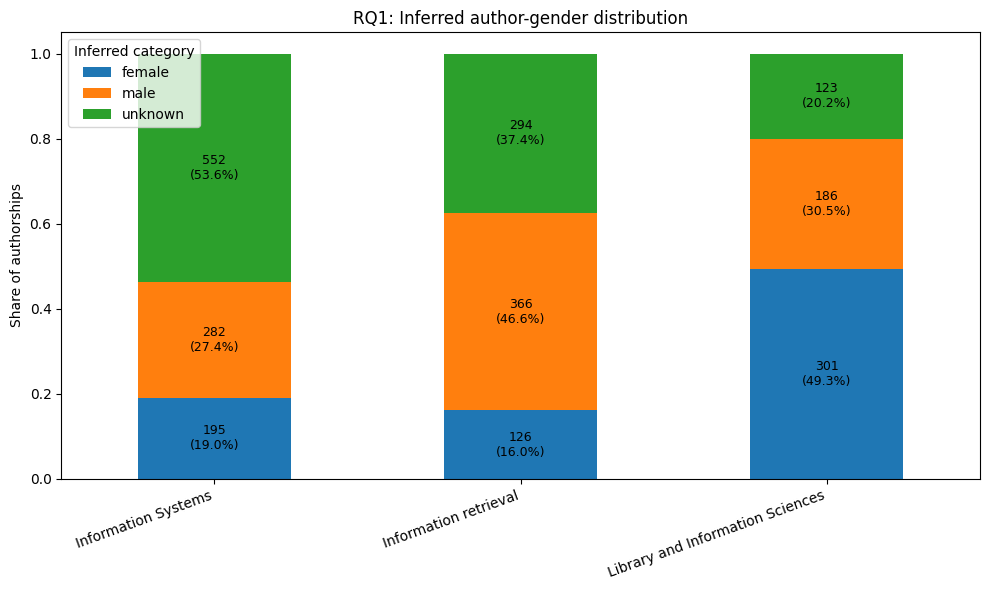

In [ ]:
rq1_plot = rq1_counts.pivot_table(
    index="corpus_name",
    columns="gender_inferred",
    values="share_all_authorships",
    fill_value=0
)

cols = [c for c in ["female", "male", "unknown"] if c in rq1_plot.columns]

ax = rq1_plot[cols].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("RQ1: Inferred author-gender distribution")
ax.set_ylabel("Share of authorships")
ax.set_xlabel("")
ax.legend(title="Inferred category")

plt.xticks(rotation=20, ha="right")

# Add count + percentage labels to each stack
for i, corpus in enumerate(rq1_plot.index):

    bottom = 0

    for gender in cols:

        share = rq1_plot.loc[corpus, gender]

        if share > 0:

            # Get count from rq1_counts
            count = rq1_counts[
                (rq1_counts["corpus_name"] == corpus) &
                (rq1_counts["gender_inferred"] == gender)
            ]["n"].iloc[0]

            # Position in the middle of the stacked section
            y_position = bottom + share / 2

            ax.text(
                i,
                y_position,
                f"{int(count)}\n({share * 100:.1f}%)",
                ha="center",
                va="center",
                fontsize=9
            )

            bottom += share

plt.tight_layout()
plt.show()

# First Author comparision

In [ ]:
rq1_first = (
    papers_df
    .groupby(["corpus_key","corpus_name","first_author_gender_inferred"])
    .size()
    .rename("n_papers")
    .reset_index()
)

rq1_first["share_within_corpus"] = (
    rq1_first["n_papers"]
    / rq1_first.groupby("corpus_key")["n_papers"].transform("sum")
)

display(rq1_first)

,corpus_key,corpus_name,first_author_gender_inferred,n_papers,share_within_corpus
0,keyword_information_retrieval,Information retrieval,female,61,0.122
1,keyword_information_retrieval,Information retrieval,male,142,0.284
2,keyword_information_retrieval,Information retrieval,unknown,297,0.594
3,subfield_1710,Information Systems,female,107,0.214
4,subfield_1710,Information Systems,male,114,0.228
5,subfield_1710,Information Systems,unknown,279,0.558
6,subfield_3309,Library and Information Sciences,female,248,0.496
7,subfield_3309,Library and Information Sciences,male,131,0.262
8,subfield_3309,Library and Information Sciences,unknown,121,0.242


### can do chi-square or other statistical measures

# RQ2: comparision between author gender and number of citations


$$[
\text{FemaleShare}_i =
\frac{F_i}{F_i + M_i}
]$$


In [ ]:
rq2_df = papers_df[
    papers_df["female_author_share_inferred"].notna()
    & papers_df["cited_by_count"].notna()
    & papers_df["publication_year"].notna()
    & (papers_df["n_authors_openalex"] > 0)
].copy()

rq2_df["log1p_citations"] = np.log1p(rq2_df["cited_by_count"])

diagnostics = rq2_df.groupby("corpus_name")["cited_by_count"].agg(
    n="size",
    mean="mean",
    median="median",
    variance="var",
    minimum="min",
    maximum="max"
).reset_index()

diagnostics["variance_to_mean"] = (
    diagnostics["variance"] /
    diagnostics["mean"].replace(0, np.nan)
)

display(diagnostics)

,corpus_name,n,mean,median,variance,minimum,maximum,variance_to_mean
0,Information Systems,259,9.961390,0.0,9747.967496,0,1580,978.575032
1,Information retrieval,230,15.926087,2.0,1966.322024,0,465,123.465483
2,Library and Information Sciences,390,1.566667,0.0,36.899143,0,64,23.552645


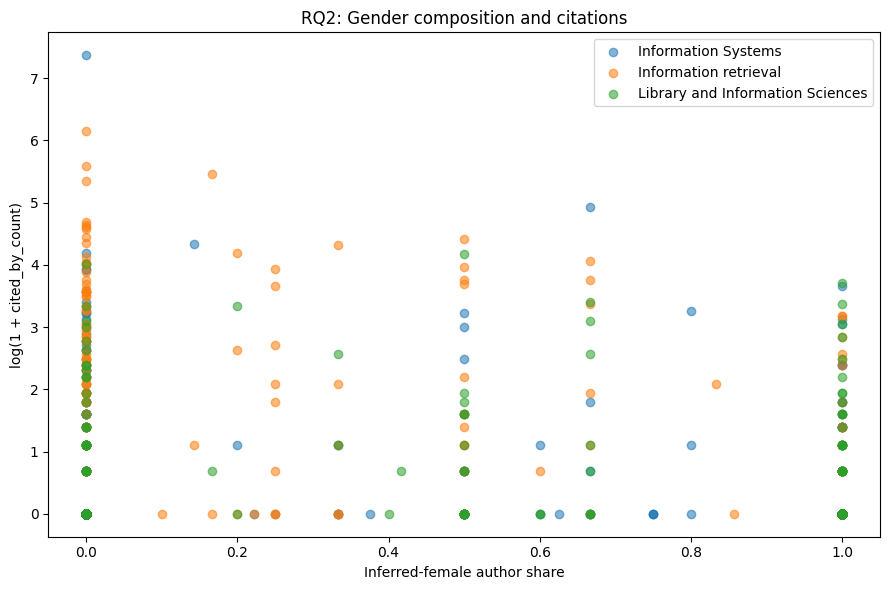

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))

for corpus_name, g in rq2_df.groupby("corpus_name"):
    ax.scatter(
        g["female_author_share_inferred"],
        g["log1p_citations"],
        alpha=0.55,
        label=corpus_name
    )

ax.set_xlabel("Inferred-female author share")
ax.set_ylabel("log(1 + cited_by_count)")
ax.set_title("RQ2: Gender composition and citations")
ax.legend()
plt.tight_layout()
plt.show()

###can do some statistics - pvalue etc

# RQ3 — First-author gender and citations

> **Do citation counts differ between papers with inferred-female and inferred-male first authors?**

Unknown first-author classifications are retained in the descriptive representation results,
but excluded from the binary female-vs-male citation comparison.

We report:

1. descriptive citation statistics;
2. Mann–Whitney U test by corpus;
3. exploratory adjusted negative-binomial regression.

In [ ]:
rq3_df = papers_df[
    papers_df["first_author_gender_inferred"].isin(["female","male"])
    & papers_df["cited_by_count"].notna()
    & papers_df["publication_year"].notna()
].copy()

rq3_summary = rq3_df.groupby(
    ["corpus_name","first_author_gender_inferred"]
)["cited_by_count"].agg(
    n="size",
    mean="mean",
    median="median",
    std="std",
    minimum="min",
    maximum="max"
).reset_index()

display(rq3_summary)

,corpus_name,first_author_gender_inferred,n,mean,median,std,minimum,maximum
0,Information Systems,female,42,2.857143,0.0,7.826071,0,38
1,Information Systems,male,33,1.909091,0.0,4.516384,0,20
2,Information retrieval,female,29,5.275862,0.0,15.120697,0,74
3,Information retrieval,male,55,23.781818,2.0,66.377900,0,465
4,Library and Information Sciences,female,90,1.511111,0.0,5.625473,0,40
5,Library and Information Sciences,male,59,1.491525,0.0,3.697030,0,19


In [ ]:
rq3_mw = []

for corpus_name, g in rq3_df.groupby("corpus_name"):
    female = g.loc[
        g["first_author_gender_inferred"] == "female",
        "cited_by_count"
    ].dropna()

    male = g.loc[
        g["first_author_gender_inferred"] == "male",
        "cited_by_count"
    ].dropna()

    if len(female) and len(male):
        u, p = stats.mannwhitneyu(
            female,
            male,
            alternative="two-sided",
            method="auto"
        )
    else:
        u, p = np.nan, np.nan

    rq3_mw.append({
        "corpus_name": corpus_name,
        "n_female_first": len(female),
        "n_male_first": len(male),
        "median_citations_female_first": female.median() if len(female) else np.nan,
        "median_citations_male_first": male.median() if len(male) else np.nan,
        "mann_whitney_U": u,
        "p_value": p
    })

rq3_mw = pd.DataFrame(rq3_mw)
display(rq3_mw)

,corpus_name,n_female_first,n_male_first,median_citations_female_first,median_citations_male_first,mann_whitney_U,p_value
0,Information Systems,42,33,0.0,0.0,669.0,0.751275
1,Information retrieval,29,55,0.0,2.0,577.0,0.029062
2,Library and Information Sciences,90,59,0.0,0.0,2511.0,0.432317


/tmp/ipykernel_6450/2590988635.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([f, m], labels=["female","male"])
/tmp/ipykernel_6450/2590988635.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([f, m], labels=["female","male"])
/tmp/ipykernel_6450/2590988635.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([f, m], labels=["female","male"])


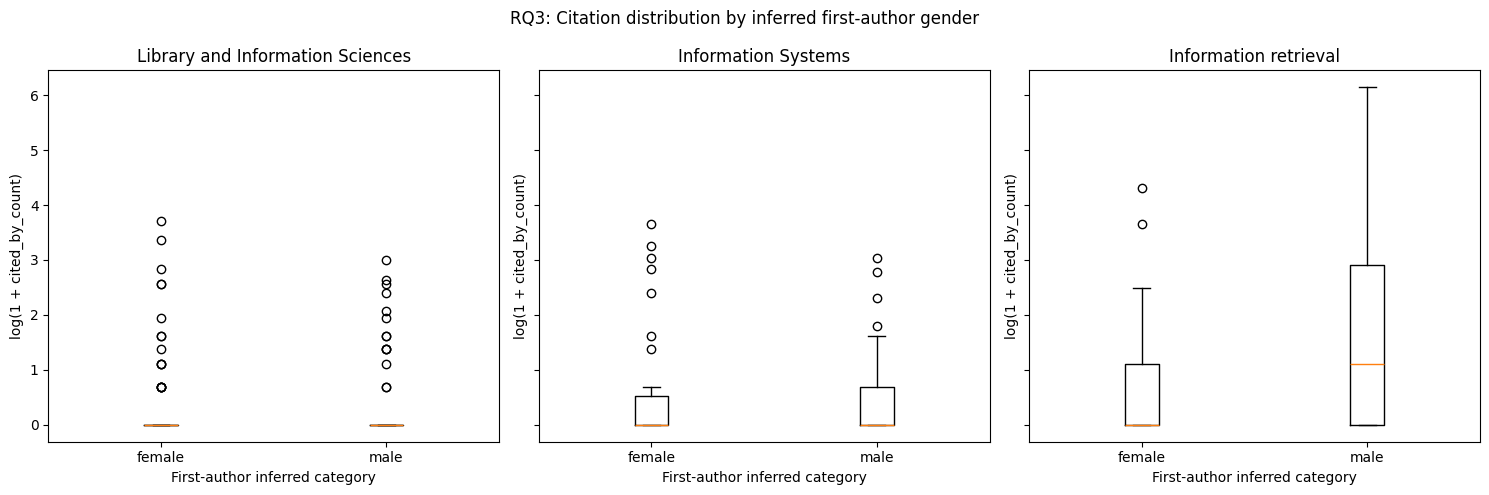

In [ ]:
rq3_df["log1p_citations"] = np.log1p(rq3_df["cited_by_count"])

corpus_names = list(rq3_df["corpus_name"].unique())
fig, axes = plt.subplots(
    1,
    len(corpus_names),
    figsize=(5 * len(corpus_names), 5),
    sharey=True
)

if len(corpus_names) == 1:
    axes = [axes]

for ax, corpus_name in zip(axes, corpus_names):
    g = rq3_df[rq3_df["corpus_name"] == corpus_name]

    f = g.loc[
        g["first_author_gender_inferred"] == "female",
        "log1p_citations"
    ]
    m = g.loc[
        g["first_author_gender_inferred"] == "male",
        "log1p_citations"
    ]

    ax.boxplot([f, m], labels=["female","male"])
    ax.set_title(corpus_name)
    ax.set_xlabel("First-author inferred category")
    ax.set_ylabel("log(1 + cited_by_count)")

fig.suptitle("RQ3: Citation distribution by inferred first-author gender")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# YEAR / DECADE CITATION ANALYSIS
# ============================================================

citation_time_df = papers_df[
    papers_df["first_author_gender_inferred"].isin(["female", "male"])
    & papers_df["publication_year"].notna()
    & papers_df["cited_by_count"].notna()
].copy()

citation_time_df["publication_year"] = (
    citation_time_df["publication_year"].astype(int)
)

citation_time_df["decade"] = (
    citation_time_df["publication_year"] // 10 * 10
)

citation_time_df["decade_label"] = (
    citation_time_df["decade"].astype(str) + "s"
)

display(
    citation_time_df[
        [
            "corpus_name",
            "publication_year",
            "decade_label",
            "first_author_gender_inferred",
            "cited_by_count"
        ]
    ].head()
)
year_gender_citations = (
    citation_time_df
    .groupby([
        "corpus_name",
        "publication_year",
        "first_author_gender_inferred"
    ])
    .agg(
        n_papers=("work_id", "size"),
        total_citations=("cited_by_count", "sum"),
        mean_citations=("cited_by_count", "mean"),
        median_citations=("cited_by_count", "median"),
        std_citations=("cited_by_count", "std"),
        min_citations=("cited_by_count", "min"),
        max_citations=("cited_by_count", "max")
    )
    .reset_index()
    .sort_values([
        "corpus_name",
        "publication_year",
        "first_author_gender_inferred"
    ])
)

display(year_gender_citations)

,corpus_name,publication_year,decade_label,first_author_gender_inferred,cited_by_count
0,Library and Information Sciences,2019,2010s,male,0
1,Library and Information Sciences,2018,2010s,male,0
2,Library and Information Sciences,1982,1980s,female,2
3,Library and Information Sciences,2018,2010s,female,0
5,Library and Information Sciences,2019,2010s,female,0


,corpus_name,publication_year,first_author_gender_inferred,n_papers,total_citations,mean_citations,median_citations,std_citations,min_citations,max_citations
0,Information Systems,1935,male,1,4,4.0,4.0,NaN,4,4
1,Information Systems,1967,male,1,0,0.0,0.0,NaN,0,0
2,Information Systems,1970,male,1,0,0.0,0.0,NaN,0,0
3,Information Systems,1977,male,1,1,1.0,1.0,NaN,1,1
4,Information Systems,1979,male,1,5,5.0,5.0,NaN,5,5
...,...,...,...,...,...,...,...,...,...,...
244,Library and Information Sciences,2024,male,2,1,0.5,0.5,0.707107,0,1
245,Library and Information Sciences,2025,female,1,0,0.0,0.0,NaN,0,0
246,Library and Information Sciences,2025,male,2,0,0.0,0.0,0.000000,0,0
247,Library and Information Sciences,2026,female,2,0,0.0,0.0,0.000000,0,0


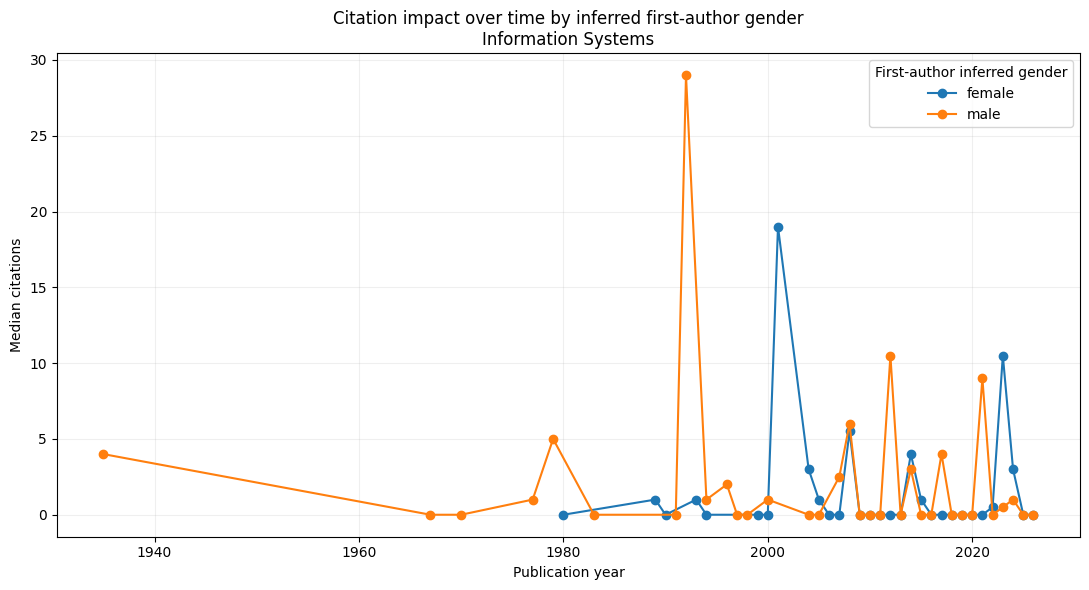

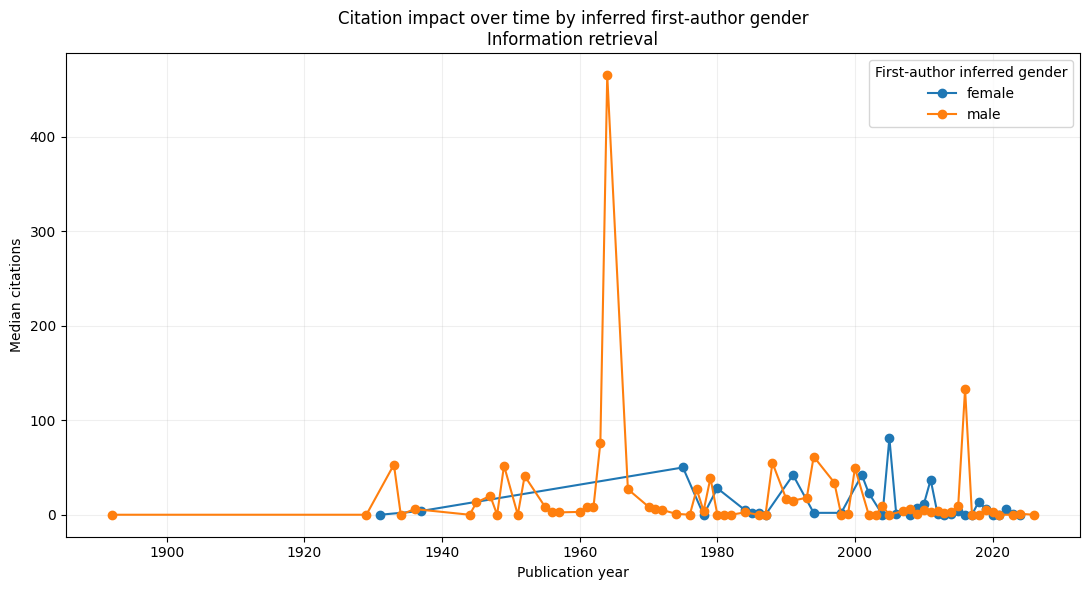

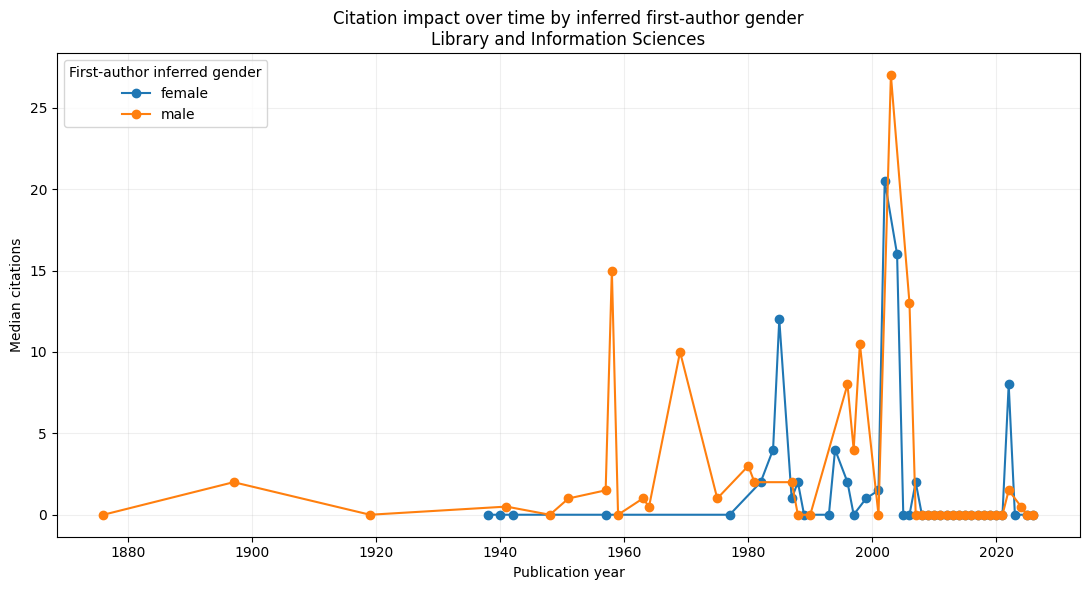

In [ ]:
year_median = (
    citation_time_df
    .groupby([
        "corpus_name",
        "publication_year",
        "first_author_gender_inferred"
    ])["cited_by_count"]
    .median()
    .reset_index(name="median_citations")
)

for corpus_name, g in year_median.groupby("corpus_name"):

    plt.figure(figsize=(11, 6))

    for gender_name, gg in g.groupby(
        "first_author_gender_inferred"
    ):
        gg = gg.sort_values("publication_year")

        plt.plot(
            gg["publication_year"],
            gg["median_citations"],
            marker="o",
            label=gender_name
        )

    plt.xlabel("Publication year")
    plt.ylabel("Median citations")
    plt.title(
        f"Citation impact over time by inferred first-author gender\n"
        f"{corpus_name}"
    )

    plt.legend(title="First-author inferred gender")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


#Note citations accumulate, hence we should use fwci something that they already provide in api